In [1]:
from pytrends.request import TrendReq
import pandas as pd
import os

pytrends = TrendReq()
keywords = ["delete facebook", "facebook privacy", "cambridge analytica"]

def get_trends(timeframe):
    pytrends.build_payload(keywords, timeframe=timeframe)
    df = pytrends.interest_over_time()
    df = df.drop(columns=["isPartial"], errors="ignore")
    df = df.reset_index()
    return df

df1 = get_trends("2015-01-01 2017-12-31")
df2 = get_trends("2018-01-01 2019-12-31")
df3 = get_trends("2020-01-01 2021-12-31")

all_trends = pd.concat([df1, df2, df3], ignore_index=True)
all_trends["date"] = pd.to_datetime(all_trends["date"])
all_trends = all_trends.drop_duplicates(subset="date")
all_trends = all_trends.sort_values("date").reset_index(drop=True)

os.makedirs("data/raw", exist_ok=True)
all_trends.to_csv("data/raw/google_trends_2015_2021.csv", index=False)

all_trends

,date,delete facebook,facebook privacy,cambridge analytica
0,2014-12-28,54,8,0
1,2015-01-04,44,41,0
2,2015-01-11,42,5,0
3,2015-01-18,41,4,0
4,2015-01-25,41,5,0
...,...,...,...,...
361,2021-11-28,55,5,5
362,2021-12-05,57,5,4
363,2021-12-12,51,4,4
364,2021-12-19,50,4,3


In [2]:
import requests
import pandas as pd
import time

def get_wiki_data(page):
    url = f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/user/{page}/daily/20150101/20211231"
    
    headers = {
        "User-Agent": "DSA210Project/1.0 (student project)"
    }
    
    response = requests.get(url, headers=headers)
    
    if response.status_code != 200:
        print("Veri alınamadı:", response.status_code)
        print(response.text)
        return None
    
    data = response.json()
    
    records = []
    for item in data["items"]:
        records.append({
            "date": pd.to_datetime(item["timestamp"][:8]),
            f"{page}_views": item["views"]
        })
    
    df = pd.DataFrame(records)
    return df


wiki_ca = get_wiki_data("Cambridge_Analytica")
time.sleep(2)
wiki_fb = get_wiki_data("Facebook")

wiki_ca_weekly = wiki_ca.set_index("date").resample("W").mean().reset_index()
wiki_fb_weekly = wiki_fb.set_index("date").resample("W").mean().reset_index()

wiki_ca_weekly

,date,Cambridge_Analytica_views
0,2016-02-14,23.666667
1,2016-02-21,21.142857
2,2016-02-28,20.428571
3,2016-03-06,10.857143
4,2016-03-13,20.142857
...,...,...
303,2021-12-05,997.285714
304,2021-12-12,990.285714
305,2021-12-19,2245.428571
306,2021-12-26,1617.285714


In [3]:
import os
os.makedirs("data/raw", exist_ok=True)

wiki_ca_weekly.to_csv("data/raw/wiki_cambridge_weekly.csv", index=False)
wiki_fb_weekly.to_csv("data/raw/wiki_facebook_weekly.csv", index=False)



In [4]:
!pip install yfinance
import yfinance as yf

meta = yf.download("META", start="2015-01-01", end="2022-01-01")

meta.head()
meta = meta.reset_index()
meta = meta[["Date", "Close"]]
meta.columns = ["date", "meta_close"]

meta.head()
meta_weekly = meta.set_index("date").resample("W").mean().reset_index()

meta_weekly

[*********************100%***********************]  1 of 1 completed


,date,meta_close
0,2015-01-04,77.839157
1,2015-01-11,76.481816
2,2015-01-18,75.146295
3,2015-01-25,76.514555
4,2015-02-01,76.088901
...,...,...
361,2021-12-05,315.587451
362,2021-12-12,323.622382
363,2021-12-19,333.101996
364,2021-12-26,328.755096


In [5]:
import os
os.makedirs("data/raw", exist_ok=True)

meta_weekly.to_csv("data/raw/meta_weekly.csv", index=False)

In [6]:
import pandas as pd

data = pd.read_csv("data/raw/google_trends_2015_2021.csv")
data["date"] = pd.to_datetime(data["date"])

data.head()

,date,delete facebook,facebook privacy,cambridge analytica
0,2014-12-28,54,8,0
1,2015-01-04,44,41,0
2,2015-01-11,42,5,0
3,2015-01-18,41,4,0
4,2015-01-25,41,5,0


In [7]:

wiki_data = pd.merge(wiki_ca_weekly, wiki_fb_weekly, on="date")

merged_data = pd.merge(data, wiki_data, on="date")

merged_data = pd.merge(merged_data, meta_weekly, on="date")

merged_data


,date,delete facebook,facebook privacy,cambridge analytica,Cambridge_Analytica_views,Facebook_views,meta_close
0,2016-02-14,37,4,0,23.666667,39385.000000,100.056810
1,2016-02-21,37,4,0,21.142857,39040.142857,102.904959
2,2016-02-28,36,4,0,20.428571,38319.857143,106.264098
3,2016-03-06,36,4,0,10.857143,38292.142857,108.083815
4,2016-03-13,37,3,0,20.142857,39592.428571,106.345457
...,...,...,...,...,...,...,...
302,2021-11-28,55,5,5,1078.000000,26913.857143,335.477364
303,2021-12-05,57,5,4,997.285714,28022.571429,315.587451
304,2021-12-12,51,4,4,990.285714,27919.571429,323.622382
305,2021-12-19,50,4,3,2245.428571,27005.000000,333.101996


In [8]:
import os

os.makedirs("data/processed", exist_ok=True)

merged_data.to_csv("data/processed/merged_data.csv", index=False)

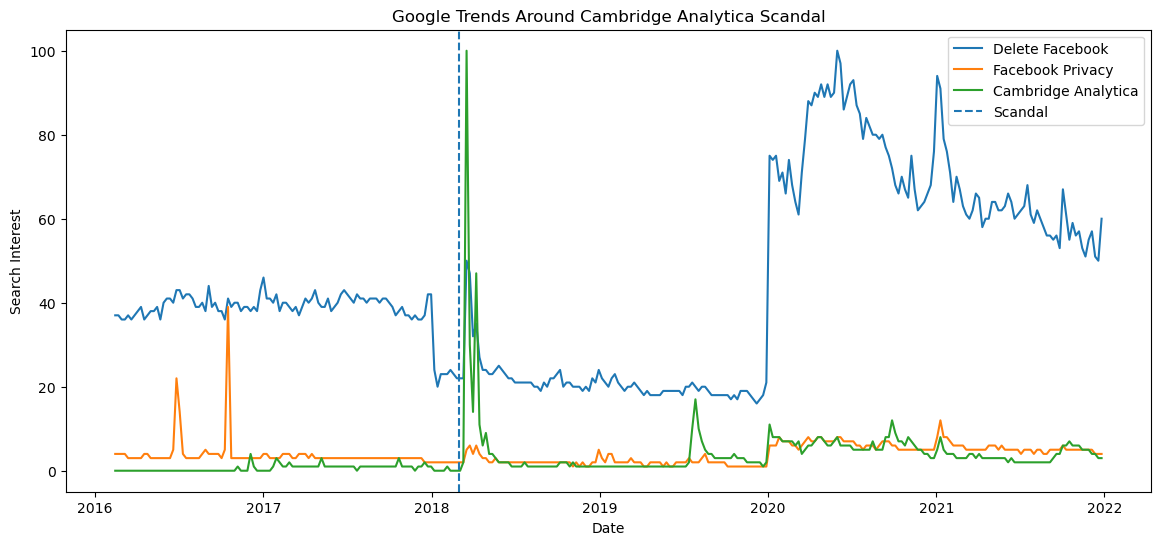

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(14,6))

plt.plot(merged_data["date"], merged_data["delete facebook"], label="Delete Facebook")
plt.plot(merged_data["date"], merged_data["facebook privacy"], label="Facebook Privacy")
plt.plot(merged_data["date"], merged_data["cambridge analytica"], label="Cambridge Analytica")

plt.axvline(pd.to_datetime("2018-03-01"), linestyle="--", label="Scandal")

plt.title("Google Trends Around Cambridge Analytica Scandal")
plt.xlabel("Date")
plt.ylabel("Search Interest")
plt.legend()

plt.show()

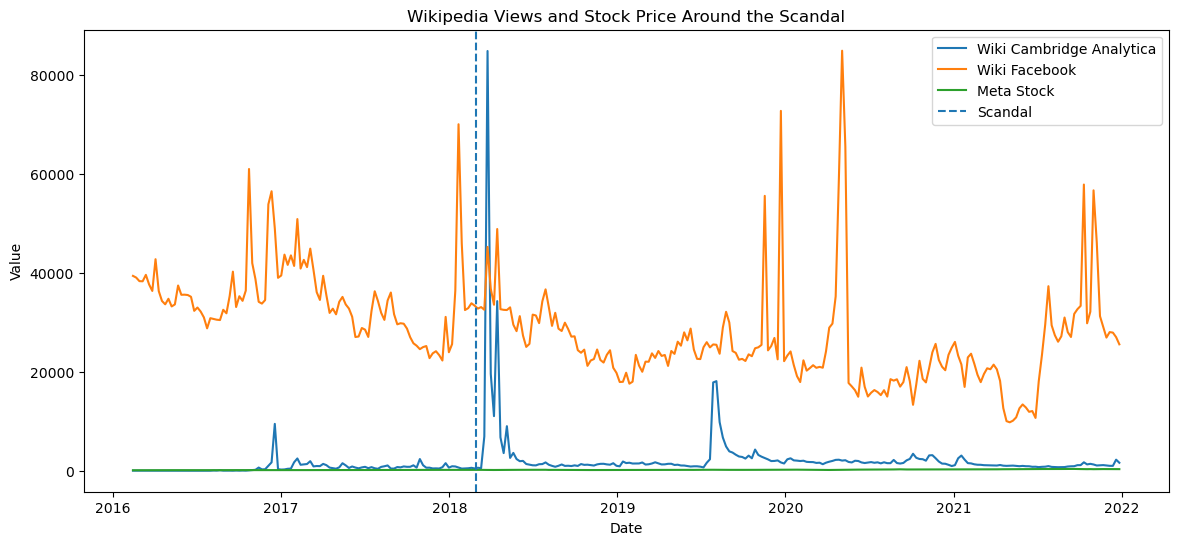

In [10]:
plt.figure(figsize=(14,6))

plt.plot(merged_data["date"], merged_data["Cambridge_Analytica_views"], label="Wiki Cambridge Analytica")
plt.plot(merged_data["date"], merged_data["Facebook_views"], label="Wiki Facebook")
plt.plot(merged_data["date"], merged_data["meta_close"], label="Meta Stock")

plt.axvline(pd.to_datetime("2018-03-01"), linestyle="--", label="Scandal")

plt.title("Wikipedia Views and Stock Price Around the Scandal")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()

plt.show()

In [11]:
from sklearn.preprocessing import MinMaxScaler

numeric_cols = [
    "delete facebook",
    "facebook privacy",
    "cambridge analytica",
    "Cambridge_Analytica_views",
    "Facebook_views",
    "meta_close"
]

scaler = MinMaxScaler()

normalized_data = merged_data.copy()
normalized_data[numeric_cols] = scaler.fit_transform(merged_data[numeric_cols])

In [12]:
normalized_data[numeric_cols].corr()

,delete facebook,facebook privacy,cambridge analytica,Cambridge_Analytica_views,Facebook_views,meta_close
delete facebook,1.000000,0.564980,0.219377,-0.035910,-0.196563,0.518758
facebook privacy,0.564980,1.000000,0.150518,0.016127,-0.074031,0.208621
cambridge analytica,0.219377,0.150518,1.000000,0.382095,-0.036451,0.150571
Cambridge_Analytica_views,-0.035910,0.016127,0.382095,1.000000,0.100074,-0.011527
Facebook_views,-0.196563,-0.074031,-0.036451,0.100074,1.000000,-0.362095
meta_close,0.518758,0.208621,0.150571,-0.011527,-0.362095,1.000000


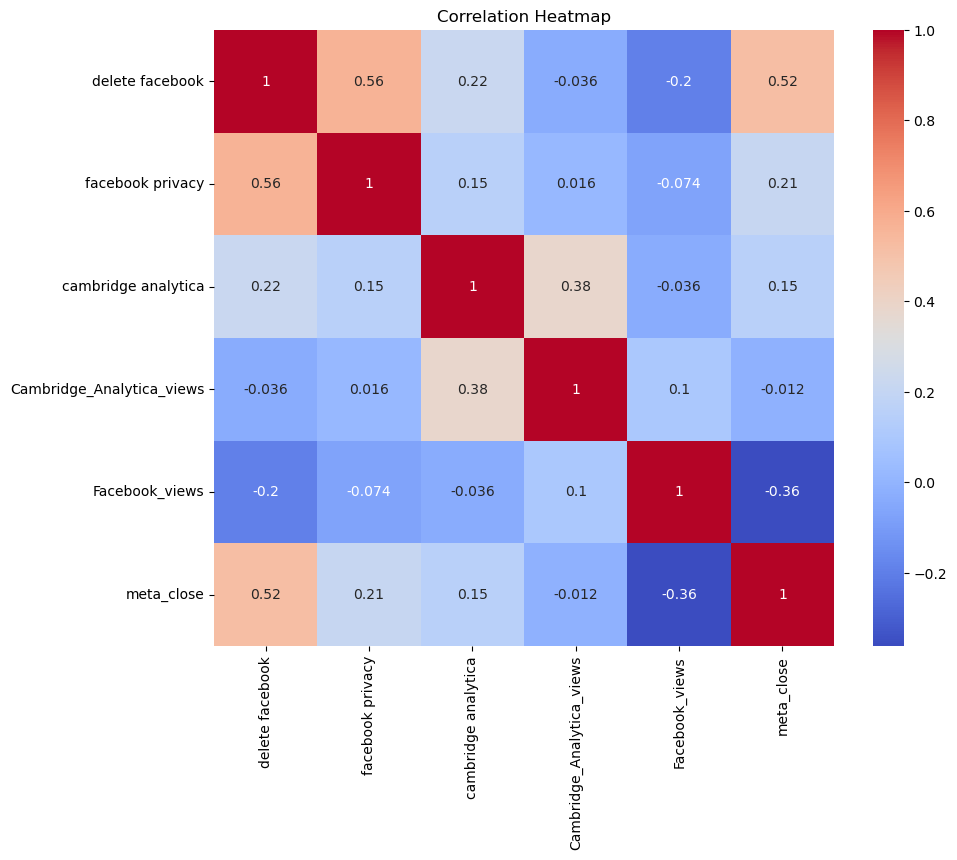

In [13]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(normalized_data[numeric_cols].corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

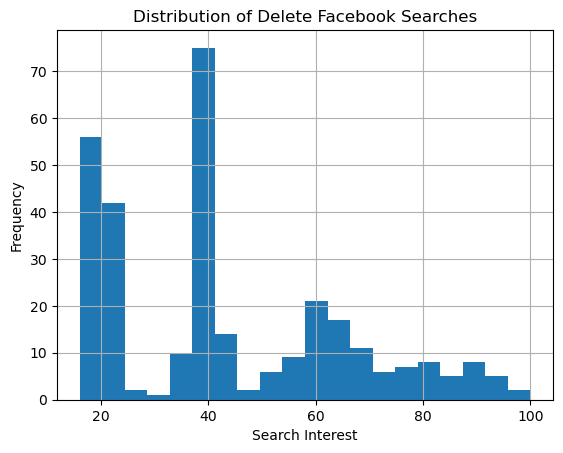

In [14]:
merged_data["delete facebook"].hist(bins=20)
plt.title("Distribution of Delete Facebook Searches")
plt.xlabel("Search Interest")
plt.ylabel("Frequency")
plt.show()

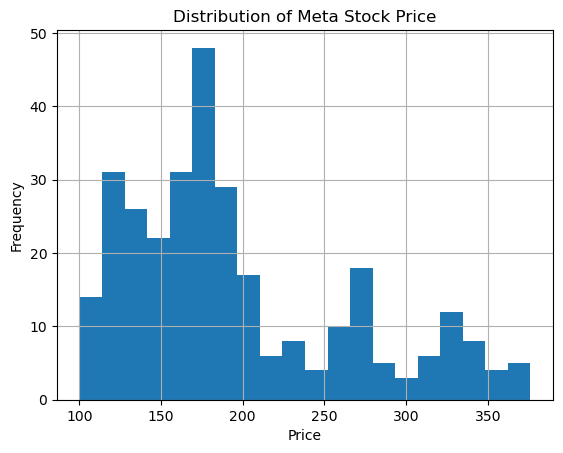

In [15]:
merged_data["meta_close"].hist(bins=20)
plt.title("Distribution of Meta Stock Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

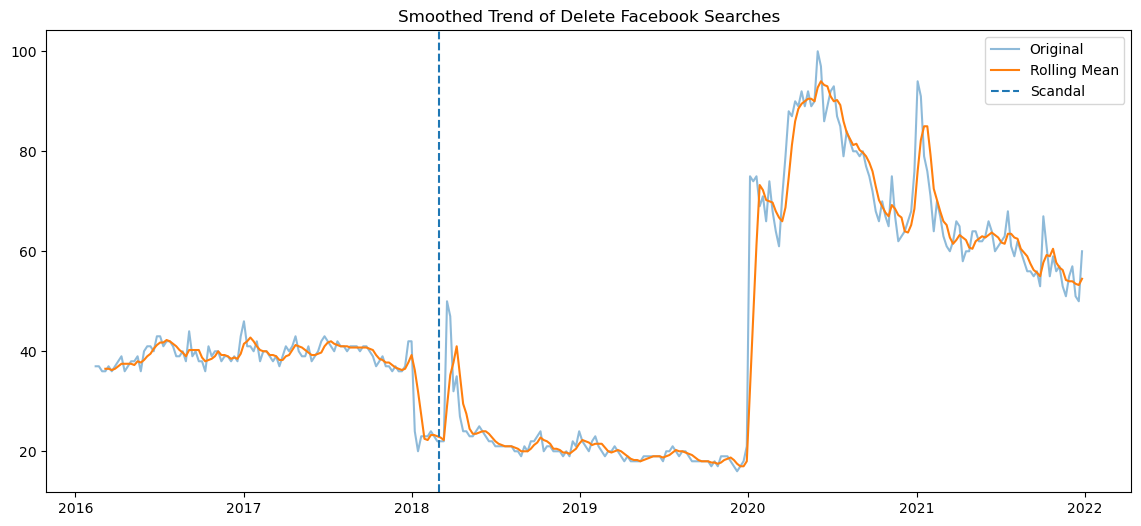

In [16]:
merged_data["delete_fb_rolling"] = merged_data["delete facebook"].rolling(4).mean()

plt.figure(figsize=(14,6))
plt.plot(merged_data["date"], merged_data["delete facebook"], alpha=0.5, label="Original")
plt.plot(merged_data["date"], merged_data["delete_fb_rolling"], label="Rolling Mean")

plt.axvline(pd.to_datetime("2018-03-01"), linestyle="--", label="Scandal")

plt.legend()
plt.title("Smoothed Trend of Delete Facebook Searches")
plt.show()

In [17]:
from scipy.stats import pearsonr

def interpret_corr(r):
    abs_r = abs(r)
    
    if abs_r < 0.2:
        strength = "very weak"
    elif abs_r < 0.4:
        strength = "weak"
    elif abs_r < 0.6:
        strength = "moderate"
    else:
        strength = "strong"
    
    if r > 0:
        direction = "positive"
    elif r < 0:
        direction = "negative"
    else:
        direction = "no"
    
    return strength, direction


def run_corr_test(df, col1, col2, name):
    r, p = pearsonr(df[col1], df[col2])
    strength, direction = interpret_corr(r)
    
    print(name)
    print("r:", round(r, 3))
    print("p-value:", p)
    
    if p < 0.05:
        print("statistically significant")
    else:
        print("not statistically significant")
    
    if direction == "no":
        print("no clear relationship")
    else:
        print(strength, direction, "relationship")
    
    print()

In [18]:
run_corr_test(normalized_data, "delete facebook", "Cambridge_Analytica_views", "H1")
run_corr_test(normalized_data, "delete facebook", "Facebook_views", "H2")
run_corr_test(normalized_data, "facebook privacy", "Cambridge_Analytica_views", "H3")
run_corr_test(normalized_data, "facebook privacy", "Facebook_views", "H4")
run_corr_test(normalized_data, "cambridge analytica", "Cambridge_Analytica_views", "H5")
run_corr_test(normalized_data, "delete facebook", "meta_close", "H6")

H1
r: -0.036
p-value: 0.530774253806213
not statistically significant
very weak negative relationship

H2
r: -0.197
p-value: 0.0005324904388199274
statistically significant
very weak negative relationship

H3
r: 0.016
p-value: 0.7783715286676213
not statistically significant
very weak positive relationship

H4
r: -0.074
p-value: 0.19579882686834194
not statistically significant
very weak negative relationship

H5
r: 0.382
p-value: 4.139471742422615e-12
statistically significant
weak positive relationship

H6
r: 0.519
p-value: 1.5070486649138758e-22
statistically significant
moderate positive relationship



In [19]:
## Machine Learning Methods

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [21]:
features = [
    "delete facebook",
    "facebook privacy",
    "cambridge analytica",
    "Cambridge_Analytica_views",
    "Facebook_views"
]

target = "meta_close"

ml_data = normalized_data[features + [target]].dropna()

X = ml_data[features]
y = ml_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2:", r2_score(y_test, lr_pred))

Linear Regression
MAE: 0.16634551011256946
RMSE: 0.2069107009507494
R2: 0.2798954456408139


In [23]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2:", r2_score(y_test, rf_pred))

Random Forest
MAE: 0.048654291280768945
RMSE: 0.06702048138391119
R2: 0.9244482132624646


In [24]:
importance_df = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

importance_df

,feature,importance
0,delete facebook,0.708229
3,Cambridge_Analytica_views,0.160921
4,Facebook_views,0.057385
1,facebook privacy,0.045064
2,cambridge analytica,0.028401


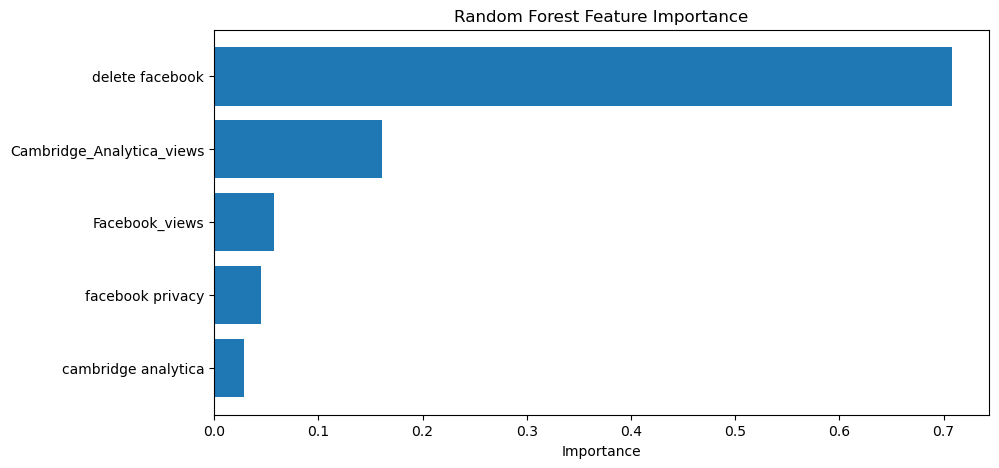

In [31]:
plt.figure(figsize=(10,5))

plt.barh(importance_df["feature"], importance_df["importance"])

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [26]:
knn = KNeighborsRegressor(n_neighbors=3)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN")
print("MAE:", mean_absolute_error(y_test, knn_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, knn_pred)))
print("R2:", r2_score(y_test, knn_pred))

KNN
MAE: 0.06205835232421378
RMSE: 0.08496669029086917
R2: 0.8785697031432302


In [27]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree")
print("MAE:", mean_absolute_error(y_test, dt_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R2:", r2_score(y_test, dt_pred))

Decision Tree
MAE: 0.06695964241300605
RMSE: 0.1110062366406141
R2: 0.7927357436976639


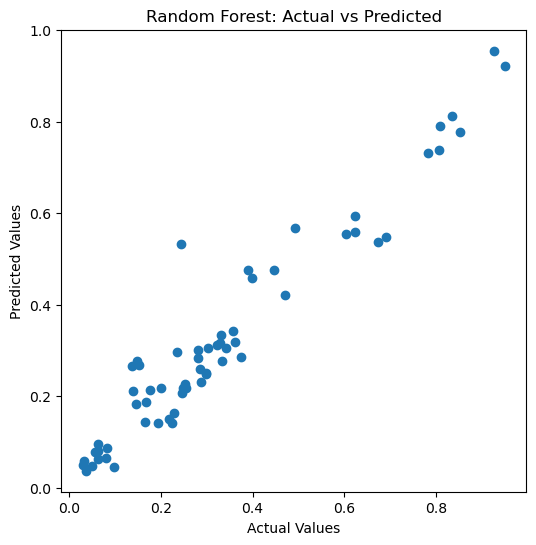

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

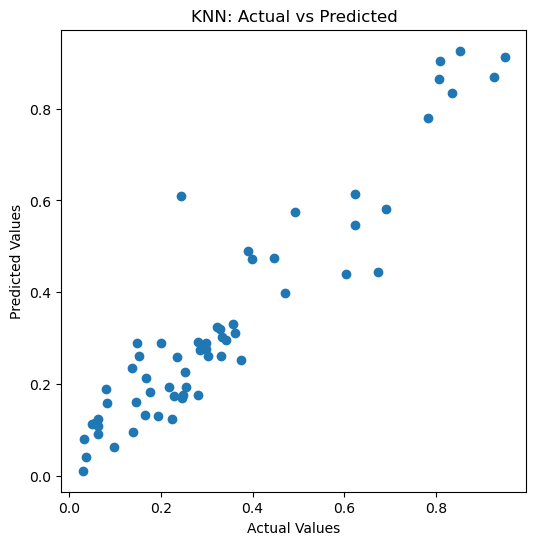

In [30]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, knn_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("KNN: Actual vs Predicted")

plt.show()